# 🐱🐶 Object Detection with YOLOv8
### Demo notebook — pretrained model on COCO dataset

---

In this notebook we will use YOLOv8 to detect objects in real images **without training anything** — the model is already ready to use.

We use cats and dogs because:
- The model detects them perfectly from the start
- Easy to understand visually
- Allows us to focus on **how YOLO works**, not on the data

In [5]:
# Install dependencies (only the first time)
!pip install ultralytics opencv-python matplotlib --quiet
!pip install -U ultralytics --quiet

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
from pathlib import Path

# Visual configuration
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 12

# Colors for bounding boxes (one per class)
COLORS = [
    '#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6',
    '#1ABC9C', '#E67E22', '#34495E', '#E91E63', '#00BCD4'
]

print('✅ Libraries loaded successfully')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/mike/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries loaded successfully


## 🧠 Step 1 — Load pretrained model

YOLOv8 comes in 5 sizes. Choose based on the speed/accuracy balance you need:

| Model | Parameters | Speed | Accuracy | Typical use |
|-------|-----------|-------|----------|-------------|
| `yolov8n` | 3M   | ⚡⚡⚡⚡ | ★★☆☆ | Prototype, CPU |
| `yolov8s` | 11M  | ⚡⚡⚡☆ | ★★★☆ | Mobile app |
| `yolov8m` | 26M  | ⚡⚡☆☆ | ★★★★ | **Best balance** |
| `yolov8l` | 44M  | ⚡☆☆☆ | ★★★★ | Powerful GPU |
| `yolov8x` | 68M  | 🐢    | ★★★★★ | Max accuracy |


In [2]:
# Load pretrained nano model on COCO
# First time downloads weights automatically (~6 MB)
model = YOLO('yolov8n.pt')

print(f'✅ Model loaded')
print(f'📦 Number of classes: {len(model.names)}')
print(f'\n🔍 First 10 classes:')
for i in range(10):
    print(f'   [{i:2d}] {model.names[i]}')

# Verify cats and dogs are included
classes_list = list(model.names.values())
print(f'\n🐱 "cat" in model: {"cat" in classes_list}')
print(f'🐶 "dog" in model: {"dog" in classes_list}')

✅ Model loaded
📦 Number of classes: 80

🔍 First 10 classes:
   [ 0] person
   [ 1] bicycle
   [ 2] car
   [ 3] motorcycle
   [ 4] airplane
   [ 5] bus
   [ 6] train
   [ 7] truck
   [ 8] boat
   [ 9] traffic light

🐱 "cat" in model: True
🐶 "dog" in model: True


## 🖼️ Step 2 — Load test images

We will use the images already in our repository.

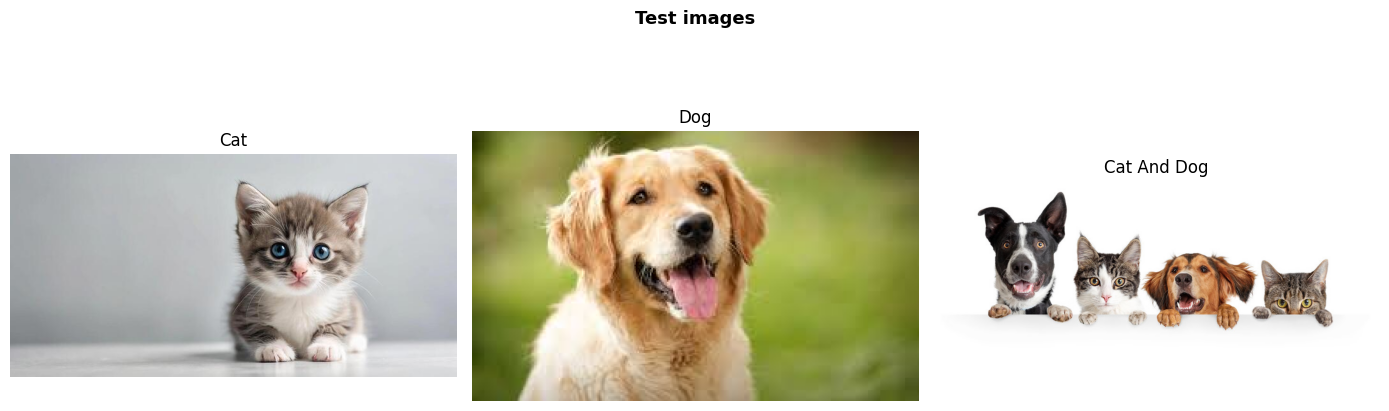

In [3]:
# Load images directly from the repo folder
rutas = {
    'cat':          '../images/cats/cat_01.jpg',
    'dog':          '../images/dogs/dog_01.jpg',
    'cat_and_dog':  '../images/combined/combined_01.jpg',
}

# Show images
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (nombre, ruta) in zip(axes, rutas.items()):
    img = cv2.cvtColor(cv2.imread(ruta), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(nombre.replace('_', ' ').title())
    ax.axis('off')
plt.suptitle('Test images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔍 Step 3 — First inference

One single line. YOLO automatically applies all the preprocessing internally: letterbox, normalization and tensor conversion.

In [4]:
# Run inference on the cat image
results = model(
    rutas['cat'],
    imgsz=640,    # input size (automatic letterbox)
    conf=0.25,    # minimum confidence to report a detection
    iou=0.45,     # IoU threshold for NMS (removes duplicates)
    verbose=False
)

# Inspect the results object
r = results[0]  # result of the first (and only) image

print('📦 What results[0] contains:')
print(f'  r.boxes      → {len(r.boxes)} detection(s)')
print(f'  r.orig_img   → original image as NumPy array {r.orig_img.shape}')
print(f'  r.names      → class dictionary {list(r.names.values())[:5]}...')
print()

print('🔍 Detail of each detection:')
for i, box in enumerate(r.boxes):
    clase_id  = int(box.cls[0])
    nombre    = model.names[clase_id]
    confianza = float(box.conf[0])
    x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]

    print(f'  [{i+1}] Class : "{nombre}" (id={clase_id})')
    print(f'       Confidence : {confianza:.2%}')
    print(f'       Bbox       : x1={x1}  y1={y1}  x2={x2}  y2={y2}')
    print()

📦 What results[0] contains:
  r.boxes      → 1 detection(s)
  r.orig_img   → original image as NumPy array (350, 700, 3)
  r.names      → class dictionary ['person', 'bicycle', 'car', 'motorcycle', 'airplane']...

🔍 Detail of each detection:
  [1] Class : "cat" (id=15)
       Confidence : 91.58%
       Bbox       : x1=341  y1=39  x2=566  y2=333



## 🎨 Step 4 — Visualize detections

Let's draw the bounding boxes on the original image to understand exactly what YOLO returns.

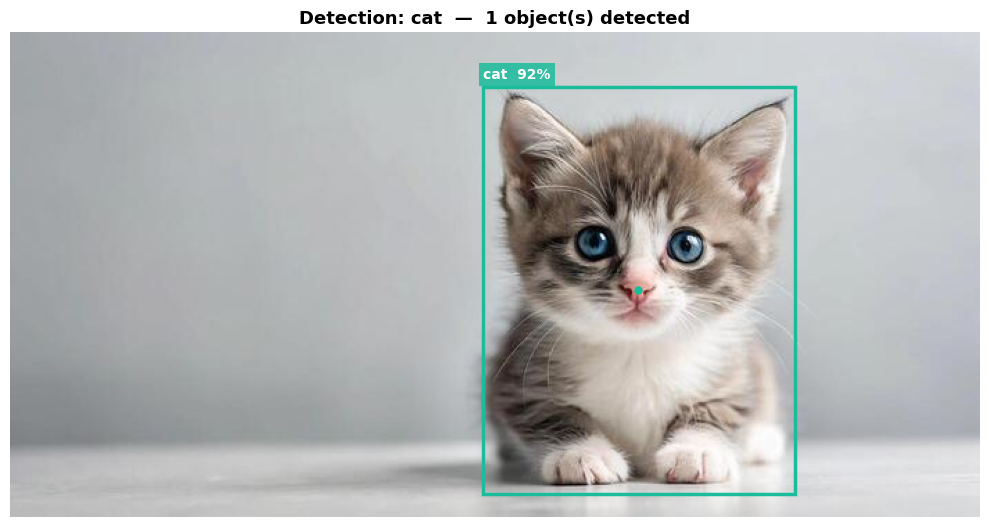

In [5]:
def draw_detections(image_path, results, title='YOLO Detections'):
    """
    Draws bounding boxes and labels on the original image.
    Shows:
    - Colored bounding box per class
    - Label with class name and confidence score
    - Center point of each bbox
    """
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(img)

    r = results[0]

    for i, box in enumerate(r.boxes):
        clase_id  = int(box.cls[0])
        nombre    = model.names[clase_id]
        confianza = float(box.conf[0])
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        ancho_bb  = x2 - x1
        alto_bb   = y2 - y1
        color     = COLORS[clase_id % len(COLORS)]

        # Bounding box
        rect = patches.Rectangle(
            (x1, y1), ancho_bb, alto_bb,
            linewidth=2.5, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        # Label with background
        label = f'{nombre}  {confianza:.0%}'
        ax.text(
            x1, y1 - 6, label,
            color='white', fontsize=10, fontweight='bold',
            bbox=dict(facecolor=color, edgecolor='none', pad=3, alpha=0.85)
        )

        # Center point of bbox
        cx, cy = x1 + ancho_bb // 2, y1 + alto_bb // 2
        ax.plot(cx, cy, 'o', color=color, markersize=5)

    ax.set_title(
        f'{title}  —  {len(r.boxes)} object(s) detected',
        fontsize=13, fontweight='bold'
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Visualize result
draw_detections(rutas['cat'], results, title='Detection: cat')

## 🧪 Step 5 — Experiment: confidence threshold

The `conf` parameter controls how confident the model must be to report a detection.

- **Low `conf` (0.1)** → detects everything, including false positives
- **High `conf` (0.8)** → only very confident detections, may miss real objects

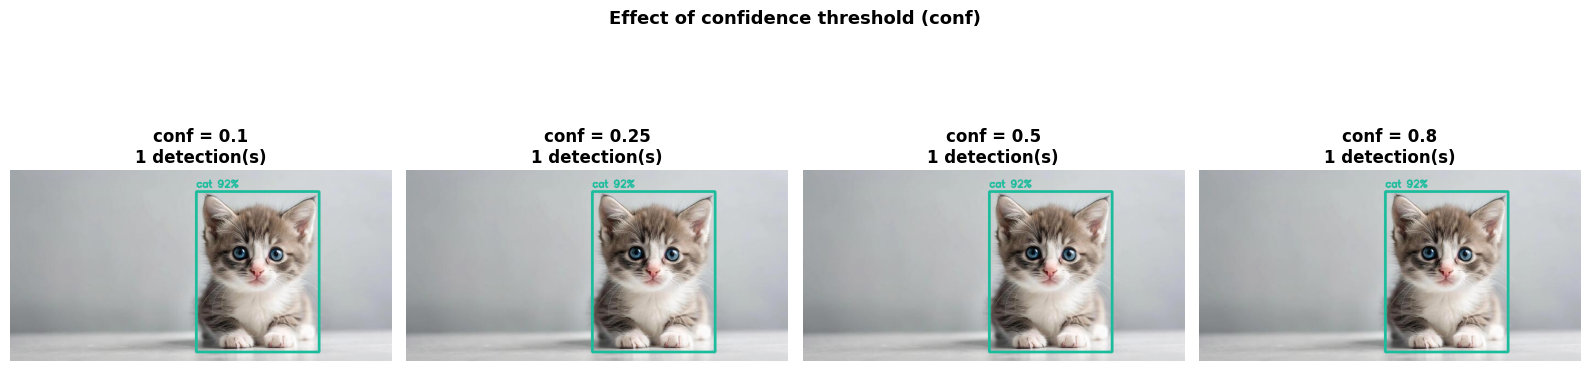

In [9]:
thresholds = [0.10, 0.25, 0.50, 0.80]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
img_base = cv2.cvtColor(cv2.imread(rutas['cat']), cv2.COLOR_BGR2RGB)

for ax, conf_val in zip(axes, thresholds):
    res = model(rutas['cat'], imgsz=640, conf=conf_val, iou=0.45, verbose=False)
    r = res[0]

    img_copy = img_base.copy()

    for box in r.boxes:
        clase_id  = int(box.cls[0])
        nombre    = model.names[clase_id]
        confianza = float(box.conf[0])
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        color_rgb = tuple(int(COLORS[clase_id % len(COLORS)].lstrip('#')[i:i+2], 16)
                          for i in (0, 2, 4))
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color_rgb, 3)
        cv2.putText(img_copy, f'{nombre} {confianza:.0%}',
                    (x1, max(y1-8, 20)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color_rgb, 2)

    ax.imshow(img_copy)
    ax.set_title(
        f'conf = {conf_val}\n{len(r.boxes)} detection(s)',
        fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Effect of confidence threshold (conf)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

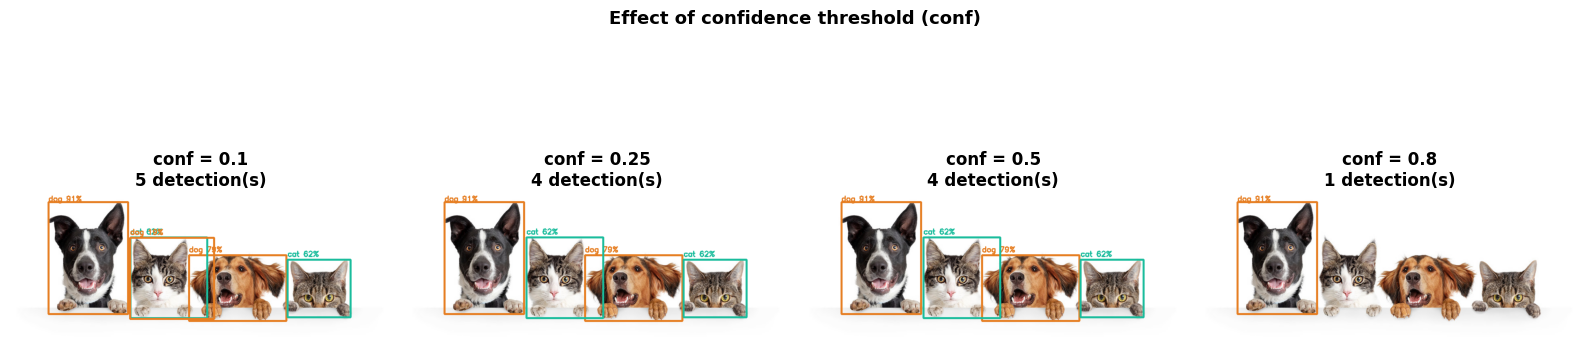

In [7]:
thresholds = [0.10, 0.25, 0.50, 0.80]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
img_base = cv2.cvtColor(cv2.imread(rutas['cat_and_dog']), cv2.COLOR_BGR2RGB)

for ax, conf_val in zip(axes, thresholds):
    res = model(rutas['cat_and_dog'], imgsz=640, conf=conf_val, iou=0.45, verbose=False)
    r = res[0]

    img_copy = img_base.copy()

    for box in r.boxes:
        clase_id  = int(box.cls[0])
        nombre    = model.names[clase_id]
        confianza = float(box.conf[0])
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        color_rgb = tuple(int(COLORS[clase_id % len(COLORS)].lstrip('#')[i:i+2], 16)
                          for i in (0, 2, 4))
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color_rgb, 3)
        cv2.putText(img_copy, f'{nombre} {confianza:.0%}',
                    (x1, max(y1-8, 20)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color_rgb, 2)

    ax.imshow(img_copy)
    ax.set_title(
        f'conf = {conf_val}\n{len(r.boxes)} detection(s)',
        fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Effect of confidence threshold (conf)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧪 Step 6 — What is IoU and NMS?

YOLO generates many overlapping detections for the same object.
**NMS (Non-Maximum Suppression)** eliminates duplicates using **IoU**.

**IoU = Intersection over Union** — measures how much two bounding boxes overlap:

- IoU close to 0 → boxes detect different objects → keep both
- IoU close to 1 → boxes detect the same object → keep only the most confident one

/tmp/ipykernel_8763/1397655379.py:72: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


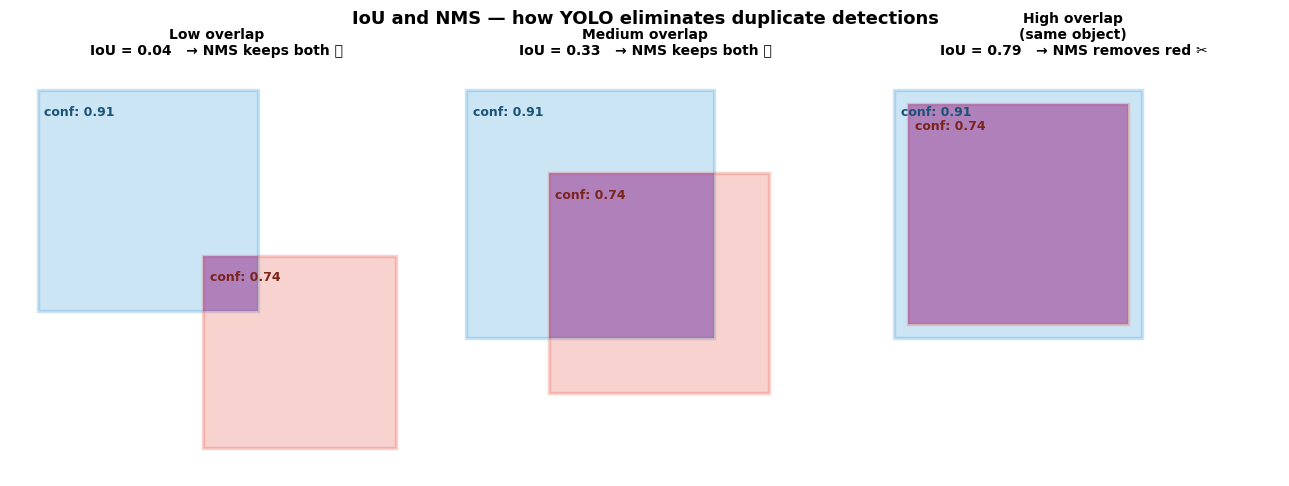

🧮 IoU examples:
  No overlap  : 0.00
  Partial     : 0.14
  Identical   : 1.00


In [11]:
def calculate_iou(box1, box2):
    """
    Calculates IoU between two bounding boxes.
    box = (x1, y1, x2, y2)
    """
    # Intersection
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])

    inter_w = max(0, xi2 - xi1)
    inter_h = max(0, yi2 - yi1)
    inter_area = inter_w * inter_h

    # Union
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area_box1 + area_box2 - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


# Visual demo with three cases
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

cases = [
    {'box1': (20, 20, 180, 180), 'box2': (140, 140, 280, 280), 'title': 'Low overlap'},
    {'box1': (20, 20, 200, 200), 'box2': (80, 80, 240, 240),   'title': 'Medium overlap'},
    {'box1': (20, 20, 200, 200), 'box2': (30, 30, 190, 190),   'title': 'High overlap\n(same object)'},
]

for ax, case in zip(axes, cases):
    b1, b2 = case['box1'], case['box2']
    iou = calculate_iou(b1, b2)

    ax.set_xlim(0, 300)
    ax.set_ylim(300, 0)
    ax.set_aspect('equal')

    # Box 1
    ax.add_patch(patches.Rectangle(
        (b1[0], b1[1]), b1[2]-b1[0], b1[3]-b1[1],
        linewidth=2.5, edgecolor='#3498DB', facecolor='#3498DB', alpha=0.25
    ))
    ax.text(b1[0]+5, b1[1]+18, 'conf: 0.91', color='#1A5276', fontsize=9, fontweight='bold')

    # Box 2
    ax.add_patch(patches.Rectangle(
        (b2[0], b2[1]), b2[2]-b2[0], b2[3]-b2[1],
        linewidth=2.5, edgecolor='#E74C3C', facecolor='#E74C3C', alpha=0.25
    ))
    ax.text(b2[0]+5, b2[1]+18, 'conf: 0.74', color='#7B241C', fontsize=9, fontweight='bold')

    # Intersection area
    xi1 = max(b1[0], b2[0]); yi1 = max(b1[1], b2[1])
    xi2 = min(b1[2], b2[2]); yi2 = min(b1[3], b2[3])
    if xi2 > xi1 and yi2 > yi1:
        ax.add_patch(patches.Rectangle(
            (xi1, yi1), xi2-xi1, yi2-yi1,
            linewidth=0, facecolor='#8E44AD', alpha=0.5
        ))

    decision = '→ NMS removes red ✂️' if iou > 0.45 else '→ NMS keeps both ✅'
    ax.set_title(
        f"{case['title']}\nIoU = {iou:.2f}   {decision}",
        fontsize=10, fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('IoU and NMS — how YOLO eliminates duplicate detections', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Manual IoU test
print('🧮 IoU examples:')
print(f'  No overlap  : {calculate_iou((0,0,100,100),(200,200,300,300)):.2f}')
print(f'  Partial     : {calculate_iou((0,0,100,100),(50,50,150,150)):.2f}')
print(f'  Identical   : {calculate_iou((0,0,100,100),(0,0,100,100)):.2f}')

## 📊 Step 7 — Batch inference: multiple images at once

YOLO can process multiple images in a single call — this is called **batch inference**.

📦 Images processed in batch: 3

  📸 cat:
     → cat         conf=93.59%
  📸 dog:
     → dog         conf=88.27%
  📸 cat_and_dog:
     → dog         conf=90.39%
     → dog         conf=78.96%
     → cat         conf=69.05%
     → cat         conf=69.01%


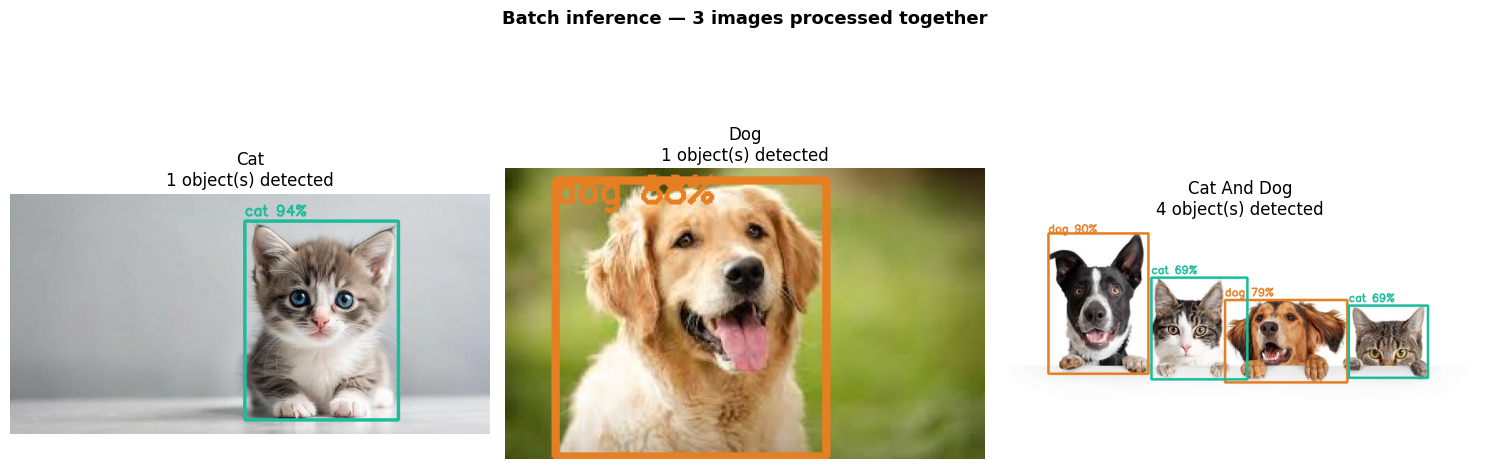

In [12]:
# Pass a list of image paths
all_results = model(
    list(rutas.values()),
    imgsz=640,
    conf=0.25,
    iou=0.45,
    verbose=False
)

print(f'📦 Images processed in batch: {len(all_results)}')
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, (nombre, ruta), r in zip(axes, rutas.items(), all_results):
    img = cv2.cvtColor(cv2.imread(ruta), cv2.COLOR_BGR2RGB).copy()

    for box in r.boxes:
        clase_id  = int(box.cls[0])
        nombre_cl = model.names[clase_id]
        confianza = float(box.conf[0])
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        color_hex = COLORS[clase_id % len(COLORS)]
        color_rgb = tuple(int(color_hex.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
        cv2.rectangle(img, (x1, y1), (x2, y2), color_rgb, 3)
        cv2.putText(img, f'{nombre_cl} {confianza:.0%}',
                    (x1, max(y1-8, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_rgb, 2)

    ax.imshow(img)
    ax.set_title(
        f"{nombre.replace('_', ' ').title()}\n{len(r.boxes)} object(s) detected"
    )
    ax.axis('off')

    print(f'  📸 {nombre}:')
    for box in r.boxes:
        cid = int(box.cls[0])
        print(f'     → {model.names[cid]:10s}  conf={float(box.conf[0]):.2%}')

plt.suptitle('Batch inference — 3 images processed together', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📋 Summary

| Concept | What it is | How to control it |
|---------|-----------|-------------------|
| **Pretrained model** | Weights already trained on COCO (80 classes) | `YOLO('yolov8n.pt')` |
| **`imgsz`** | Input size (automatic letterbox) | `imgsz=640` |
| **`conf`** | Minimum confidence threshold | `conf=0.25` |
| **`iou`** | IoU threshold for NMS | `iou=0.45` |
| **`box.xyxy`** | Bounding box coordinates in pixels | `box.xyxy[0]` |
| **`box.conf`** | Confidence score of the detection | `float(box.conf[0])` |
| **`box.cls`** | Numeric ID of the detected class | `model.names[int(box.cls[0])]` |

---

### 🗓️ Next step: Fine-tuning on a custom dataset